<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Machine-Learning/blob/main/Indian_Liver_Patient_Prediction_Using_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:
   age  gender  tot_bilirubin  direct_bilirubin  tot_proteins  albumin  \
0   65  Female            0.7               0.1           187       16   
1   62    Male           10.9               5.5           699       64   
2   62    Male            7.3               4.1           490       60   
3   58    Male            1.0               0.4           182       14   
4   72    Male            3.9               2.0           195       27   

   ag_ratio  sgpt  sgot  alkphos  is_patient  
0        18   6.8   3.3     0.90           1  
1       100   7.5   3.2     0.74           1  
2        68   7.0   3.3     0.89           1  
3        20   6.8   3.4     1.00           1  
4        59   7.3   2.4     0.40           1  

Missing values in dataset:
age                 0
gender              0
tot_bilirubin       0
direct_bilirubin    0
tot_proteins        0
albumin             0
ag_ratio            0
sgpt                0
sgot                0
alkphos             4
is_patient      

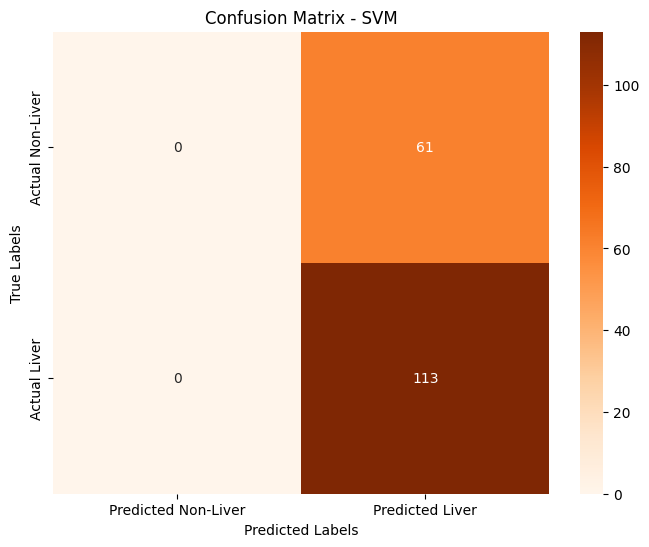

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Load Dataset
df = pd.read_csv("Indian Liver Patient Dataset (ILPD).csv")

print("Dataset:")
print(df.head())

# Check missing values
print("\nMissing values in dataset:")
print(df.isnull().sum())

# Drop rows with missing values
df = df.dropna()

print("\nDataset after dropping missing values:")
print(df.head())

# Encode Gender column
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

# Separate features and target
X = df.drop('is_patient', axis=1)
y = df['is_patient']

# Convert target: 1 = Liver patient, 2 = Non-liver → convert to binary
y = y.map({1: 1, 2: 0})

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Prediction
y_pred = svm_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Oranges", fmt='d',
            xticklabels=['Predicted Non-Liver', 'Predicted Liver'],
            yticklabels=['Actual Non-Liver', 'Actual Liver'])

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - SVM")

plt.show()